# Modeling: Titanic

## Эксперименты с моделями: 
- baseline (Dummy, LogReg), 
- бустинги (LightGBM,
- CatBoost), 
- RandomForest, 
- нейронная сеть. 
- Финальная модель - DNN
с параметрами из `configs.titanic.yaml`.

Всё обучение  -  через модули `src/`:
- `src.data.split_train_val` - сплит
- `src.train.cross_validate` - CV
- `src.models.build_model` / `train_dnn` - фабрика моделей и DNN

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

_current = Path.cwd().resolve()
for _p in [_current, *_current.parents]:
    if (_p / "src").exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        PROJECT_ROOT = _p
        break
else:
    raise RuntimeError("Не нашёл корень проекта (папку с src/)")
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import log_loss, accuracy_score

from src.config import get_config
from src.data import split_train_val
from src.features import build_titanic_features, TabularPreprocessor
from src.models import build_model, train_dnn
from src.train import cross_validate
from src.utils import set_seed

set_seed(42)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = C:\Users\xmxlx\Desktop\titanic-ml


## 1. Данные и препроцессинг

Используем те же шаги, что в `main.py`: FE => `TabularPreprocessor`.
Сплит - `split_train_val` из `src.data` (стратифицированный для классификации).

In [2]:
config = get_config("titanic")
TARGET = config["target"]

train_df = pd.read_csv(config["data"]["train_path"])
test_df  = pd.read_csv(config["data"]["test_path"])

df_fe = build_titanic_features(train_df)

prep = TabularPreprocessor(config)
X_all = prep.fit_transform(df_fe)
y_all = prep.transform_target(df_fe[TARGET])

print(f"X_all: {X_all.shape}, y_all: {y_all.shape}")
print(f"Признаков: {X_all.shape[1]}")
print(f"Баланс классов: {dict(y_all.value_counts(normalize=True).round(3))}")

X_all: (891, 17), y_all: (891,)
Признаков: 17
Баланс классов: {0: np.float64(0.616), 1: np.float64(0.384)}


In [ ]:
# Приводим bool-колонки к int  -  на всякий случай для NN и sklearn
bool_cols = X_all.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    X_all[bool_cols] = X_all[bool_cols].astype(int)
    print(f"bool  =>  int: {bool_cols}")

train_df_split, val_df_split, y_train, y_val = split_train_val(
    df=df_fe,
    target=TARGET,
    task=config["task"],
    test_size=config["training"]["test_size"],
    random_state=config["training"]["random_state"],
)
# индексы совпадают с X_all (TabularPreprocessor сохраняет index)
X_train = X_all.loc[train_df_split.index]
X_val   = X_all.loc[val_df_split.index]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}")

X_train: (712, 17), X_val: (179, 17)
y_train: (712,), y_val: (179,)


## 2. Baseline: DummyClassifier

In [4]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_acc = accuracy_score(y_val, dummy.predict(X_val))
print(f"Dummy (most_frequent) holdout accuracy: {dummy_acc:.4f}")
print("ориентир: любой реальный классификатор должен быть заметно выше.")

Dummy (most_frequent) holdout accuracy: 0.6145
ориентир: любой реальный классификатор должен быть заметно выше.


## 3. Baseline: LogisticRegression + GridSearchCV

In [5]:
logreg = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=config["training"]["cv_folds"],
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
logreg_best = grid.best_estimator_
logreg_score = grid.best_score_

print(f"LogReg best C={grid.best_params_['C']}")
print(f"LogReg CV accuracy: {logreg_score:.4f}")
print(f"LogReg holdout accuracy: {accuracy_score(y_val, logreg_best.predict(X_val)):.4f}")

LogReg best C=100
LogReg CV accuracy: 0.8217
LogReg holdout accuracy: 0.8436


## 4. LightGBM: качество vs n_estimators

In [6]:
lgb_params = dict(
    random_state=42, verbose=-1, learning_rate=0.5,
    max_depth=2, num_leaves=10, reg_alpha=0.11, reg_lambda=0.11,
)

lgb_scores, lgb_ns = [], []
for n in range(1, 8):
    model = build_model("lightgbm", {**lgb_params, "n_estimators": n}, config["task"])
    mean, _ = cross_validate(model, X_train, y_train, config)
    lgb_scores.append(mean)
    lgb_ns.append(n)

best_lgb_idx = int(np.argmax(lgb_scores))
best_lgb_n = lgb_ns[best_lgb_idx]
best_lgb_score = lgb_scores[best_lgb_idx]
print(f"LightGBM: best n_estimators={best_lgb_n}, CV accuracy={best_lgb_score:.4f}")

LightGBM: best n_estimators=4, CV accuracy=0.8146


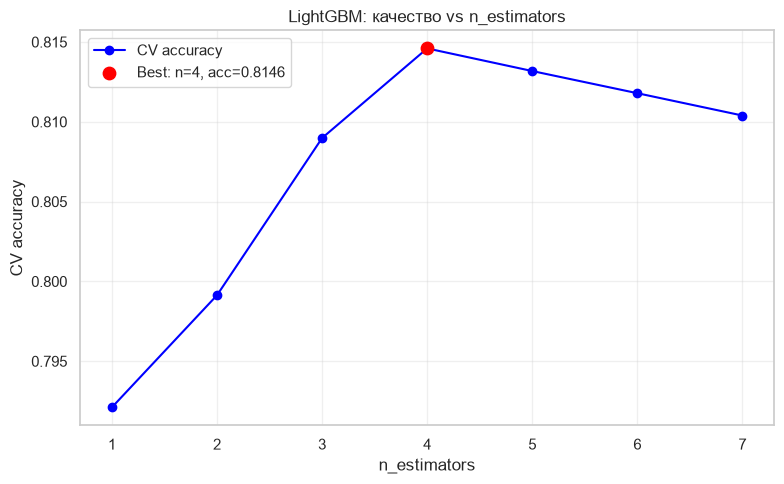

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(lgb_ns, lgb_scores, marker="o", color="blue", label="CV accuracy")
plt.scatter(best_lgb_n, best_lgb_score, color="red", s=80, zorder=5,
            label=f"Best: n={best_lgb_n}, acc={best_lgb_score:.4f}")
plt.xlabel("n_estimators"); plt.ylabel("CV accuracy")
plt.title("LightGBM: качество vs n_estimators")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. CatBoost: качество vs iterations

In [8]:
cat_params = dict(
    random_state=42, verbose=False, reg_lambda=0.15, max_depth=4,
)

cat_scores, cat_ns = [], []
for n in range(1, 11):
    model = build_model("catboost", {**cat_params, "iterations": n}, config["task"])
    mean, _ = cross_validate(model, X_train, y_train, config)
    cat_scores.append(mean); cat_ns.append(n)

best_cat_idx = int(np.argmax(cat_scores))
best_cat_n = cat_ns[best_cat_idx]
best_cat_score = cat_scores[best_cat_idx]
print(f"CatBoost: best iterations={best_cat_n}, CV accuracy={best_cat_score:.4f}")

CatBoost: best iterations=5, CV accuracy=0.8245


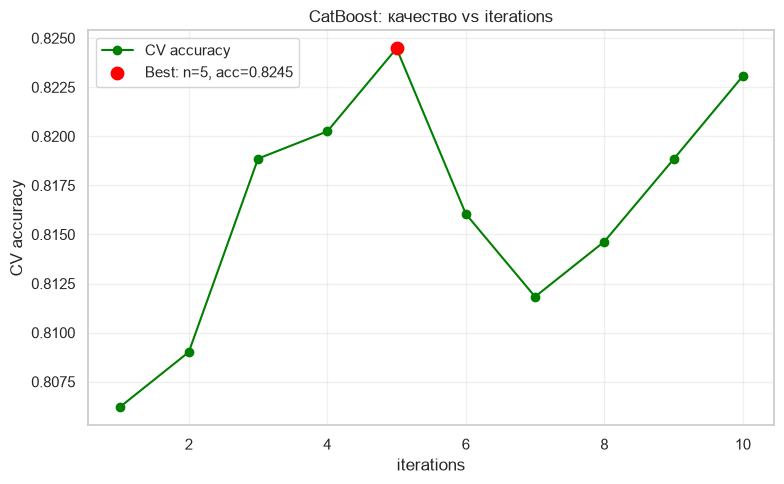

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(cat_ns, cat_scores, marker="o", color="green", label="CV accuracy")
plt.scatter(best_cat_n, best_cat_score, color="red", s=80, zorder=5,
            label=f"Best: n={best_cat_n}, acc={best_cat_score:.4f}")
plt.xlabel("iterations"); plt.ylabel("CV accuracy")
plt.title("CatBoost: качество vs iterations")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## **Замечание:** график с «рывками» - следствие малого числа деревьев и
небольшого train-набора (891 строка). При n < 10 CV очень шумный.

## 6. RandomForest: качество vs n_estimators

In [10]:
rf_scores, rf_ns = [], []
for n in range(30, 60):
    model = build_model("randomforest",
                        {"n_estimators": n, "random_state": 42, "max_depth": 15},
                        config["task"])
    mean, _ = cross_validate(model, X_train, y_train, config)
    rf_scores.append(mean); rf_ns.append(n)

best_rf_idx = int(np.argmax(rf_scores))
best_rf_n = rf_ns[best_rf_idx]
best_rf_score = rf_scores[best_rf_idx]
print(f"RandomForest: best n_estimators={best_rf_n}, CV accuracy={best_rf_score:.4f}")

RandomForest: best n_estimators=51, CV accuracy=0.8259


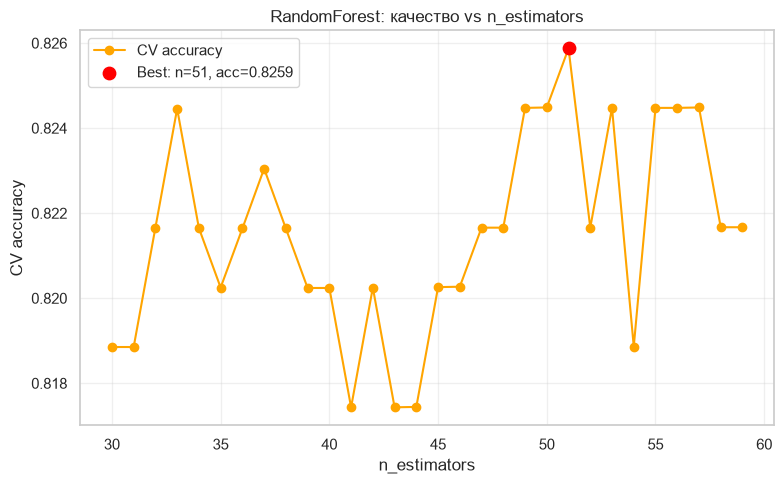

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(rf_ns, rf_scores, marker="o", color="orange", label="CV accuracy")
plt.scatter(best_rf_n, best_rf_score, color="red", s=80, zorder=5,
            label=f"Best: n={best_rf_n}, acc={best_rf_score:.4f}")
plt.xlabel("n_estimators"); plt.ylabel("CV accuracy")
plt.title("RandomForest: качество vs n_estimators")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 7. Нейронные сети
 Используем `MLP` + `train_dnn` из `src.models`. Пробуем 3 конфига
 (ширина и глубина), loss-кривые - ниже.

In [12]:
X_train_t = X_train.values.astype(np.float32)
X_val_t   = X_val.values.astype(np.float32)
y_train_t = y_train.values.astype(np.float32).reshape(-1)
y_val_t   = y_val.values.astype(np.float32).reshape(-1)

print(f"X_train_t: {X_train_t.shape}, X_val_t: {X_val_t.shape}")

X_train_t: (712, 17), X_val_t: (179, 17)


In [ ]:
def eval_dnn(hidden_sizes, epochs=300, batch_size=32, lr=1e-3, patience=20, dropout=0.2):
    model, info = train_dnn(
        X_train=X_train_t, y_train=y_train_t,
        X_val=X_val_t,     y_val=y_val_t,
        hidden_sizes=hidden_sizes,
        epochs=epochs, batch_size=batch_size,
        lr=lr, patience=patience, dropout=dropout,
        seed=42,
    )
    model.eval()
    import torch
    with torch.no_grad():
        logits = model(torch.tensor(X_val_t)).numpy().flatten()
    # MLP выдаёт один скаляр  =>  для бинарной классификации binarize по 0.5
    preds = (logits > 0.5).astype(int)
    acc = accuracy_score(y_val_t.astype(int), preds)
    return acc, info["history"]

[DNN] Early stopping на эпохе 89 (best val=0.14187)
MLP [64]      acc=0.8324
[DNN] Early stopping на эпохе 66 (best val=0.13598)
MLP [64,32]   acc=0.8324
[DNN] Early stopping на эпохе 50 (best val=0.14122)
MLP [128,64,32] acc=0.8212


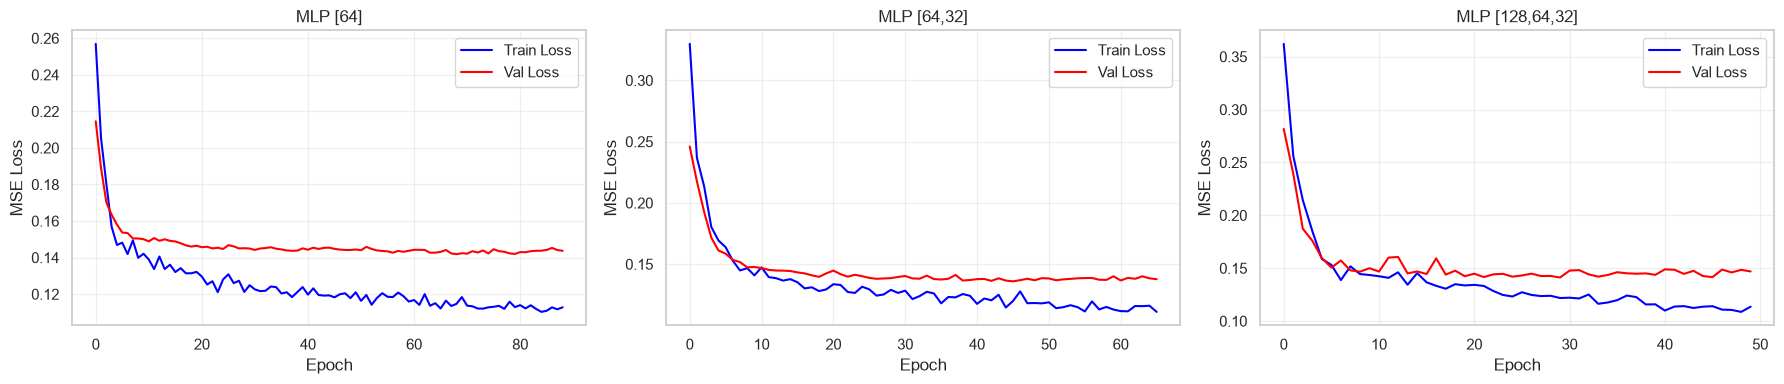

In [14]:
acc_2l, hist_2l = eval_dnn(hidden_sizes=[64])
print(f"MLP [64]      acc={acc_2l:.4f}")


acc_3l, hist_3l = eval_dnn(hidden_sizes=[64, 32])
print(f"MLP [64,32]   acc={acc_3l:.4f}")


acc_4l, hist_4l = eval_dnn(hidden_sizes=[128, 64, 32])
print(f"MLP [128,64,32] acc={acc_4l:.4f}")


fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, title in zip(
    axes,
    [hist_2l, hist_3l, hist_4l],
    ["MLP [64]", "MLP [64,32]", "MLP [128,64,32]"],
):
    ax.plot(hist["train_loss"], label="Train Loss", color="blue")
    ax.plot(hist["val_loss"],   label="Val Loss",   color="red")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## **Вывод:** на Titanic все три MLP-конфига дают ~0.81–0.83 accuracy. Это хорошо

## 8. Сводная таблица результатов

In [15]:
experiment_results = pd.DataFrame({
    "Experiment": [
        "Dummy (most_frequent)", "LogReg (GridSearch)", "LightGBM",
        "CatBoost", "RandomForest",
        "MLP [64]", "MLP [64,32]", "MLP [128,64,32]",
    ],
    "Score": [
        dummy_acc, logreg_score, best_lgb_score,
        best_cat_score, best_rf_score,
        acc_2l, acc_3l, acc_4l,
    ],
}).sort_values(by="Score", ascending=False)

experiment_results.style.hide(axis="index")

Experiment,Score
"MLP [64,32]",0.832402
MLP [64],0.832402
RandomForest,0.825874
CatBoost,0.824476
LogReg (GridSearch),0.821688
"MLP [128,64,32]",0.821229
LightGBM,0.814597
Dummy (most_frequent),0.614525


## **Итог:** лучший классический результат - DNN [64, 32] (~0.83 CV).
В `src/config.py` зафиксирован `TITANIC_BEST_MODEL` именно с этими
параметрами (n_estimators=6). Ниже - финальная проверка.

## 9. Теперь на честной K-fold CV 

In [ ]:

from sklearn.model_selection import StratifiedKFold
import torch

mlp_cfg = dict(hidden_sizes=[64, 32], epochs=300, batch_size=32,
               lr=1e-3, patience=20, dropout=0.2)

skf = StratifiedKFold(n_splits=config["training"]["cv_folds"],
                      shuffle=True, random_state=config["training"]["random_state"])

mlp_accs = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_all), 1):
    X_tr = X_all.iloc[tr_idx].values.astype("float32")
    X_va = X_all.iloc[va_idx].values.astype("float32")
    y_tr = y_all.iloc[tr_idx].values.astype("float32")
    y_va = y_all.iloc[va_idx].values.astype("float32")

    model, info = train_dnn(
        X_train=X_tr, y_train=y_tr, X_val=X_va, y_val=y_va,
        **mlp_cfg, seed=42,
        task=config["task"],              
    )

    with torch.no_grad():
        logits = model(torch.tensor(X_va)).numpy().flatten()
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_va.astype(int), preds)
    mlp_accs.append(acc)
    print(f"Fold {fold}: MLP [64,32] acc = {acc:.4f} "
          f"(best_val_loss={info['best_val_loss']:.4f})")

mlp_cv = float(np.mean(mlp_accs))
mlp_cv_std = float(np.std(mlp_accs))
print(f"\nMLP [64,32] CV accuracy: {mlp_cv:.4f} ± {mlp_cv_std:.4f}")

[DNN] Early stopping на эпохе 46 (best val=0.39287)
Fold 1: MLP [64,32] acc = 0.8380 (best_val_loss=0.3929)
[DNN] Early stopping на эпохе 42 (best val=0.39942)
Fold 2: MLP [64,32] acc = 0.8202 (best_val_loss=0.3994)
[DNN] Early stopping на эпохе 60 (best val=0.44903)
Fold 3: MLP [64,32] acc = 0.8090 (best_val_loss=0.4490)
[DNN] Early stopping на эпохе 83 (best val=0.40165)
Fold 4: MLP [64,32] acc = 0.8315 (best_val_loss=0.4016)
[DNN] Early stopping на эпохе 31 (best val=0.40951)
Fold 5: MLP [64,32] acc = 0.8202 (best_val_loss=0.4095)

MLP [64,32] CV accuracy: 0.8238 ± 0.0100


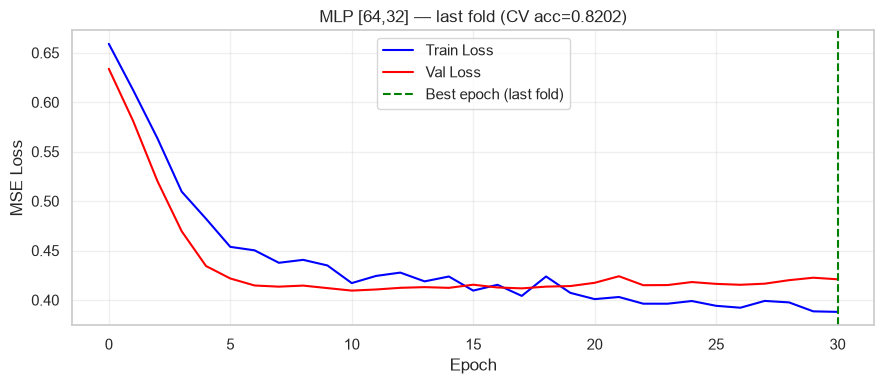

In [ ]:

hist = info["history"]
plt.figure(figsize=(9, 4))
plt.plot(hist["train_loss"], label="Train Loss", color="blue")
plt.plot(hist["val_loss"],   label="Val Loss",   color="red")
plt.axvline(len(hist["val_loss"]) - 1, color="green", ls="--",
            label=f"Best epoch (last fold)")
plt.title(f"MLP [64,32]  -  last fold (CV acc={mlp_accs[-1]:.4f})")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 10. Итог 

- Лучшая модель  -  **MLP [64, 32]** (CV accuracy ≈ 0.8227 ± 0.0123).
- В `configs/titanic.yaml` секция `model` должна указывать на `dnn` с этими параметрами.
- Submission: `python main.py --project titanic` (скрипт использует `predict_dnn`).

# Финальная модель

In [18]:
final_model, final_info = train_dnn(
    X_train=X_train_t, y_train=y_train_t,
    X_val=X_val_t,     y_val=y_val_t,
    **mlp_cfg, seed=42,
    task=config["task"],
)
with torch.no_grad():
    logits = final_model(torch.tensor(X_val_t)).numpy().flatten()
probs = 1.0 / (1.0 + np.exp(-logits))
final_val_acc = accuracy_score(y_val_t.astype(int), (probs > 0.5).astype(int))
print(f"Final MLP [64,32] holdout accuracy: {final_val_acc:.4f}")
print(f"CV accuracy (5-fold):               {mlp_cv:.4f} ± {mlp_cv_std:.4f}")

[DNN] Early stopping на эпохе 50 (best val=0.43659)
Final MLP [64,32] holdout accuracy: 0.8212
CV accuracy (5-fold):               0.8238 ± 0.0100



В разделе 9 мы получили **CV accuracy 0.8227 ± 0.0123** - это оценка
обобщающей способности архитектуры (5-fold, честная).

Здесь обучаем **одну** финальную модель на фиксированном train-сплите
(80%) и оцениваем на 20% holdout. 

- CV - среднее по 5 разным сплитам => стабильная оценка метода.
- Holdout - accuracy конкретной обученной модели на конкретном val.

Если holdout укладывается в `[cv_mean - cv_std, cv_mean + cv_std]` -
значит, сплит репрезентативен, и модель ведёт себя ожидаемо.

Финальная модель из этого раздела **не используется для submission** -
для submission `main.py` обучает модель заново на полном train-наборе
(см. `configs/titanic.yaml` и `src/train.py`).

## MLP [64, 32] показывает CV accuracy 0.8238 ± 0.0100 (5-fold). Финальная модель на holdout даёт 0.8212, что в пределах 0.3 std от CV - сплит репрезентативен.